# M9.0 — Per-angle expert xyz mean

Plan: [`plans/milestone_09/09_camera_view_fusion_plan.md`](../../plans/milestone_09/09_camera_view_fusion_plan.md).  
Final Report M9 Steps 1–2 use a **shared-trunk** xyz-mean control. This notebook is the **per-angle expert** baseline (one WIN 3J model per sampled camera angle, then `mean_j(xyz_j)`).

**Conclusion:** Averaging independent experts only modestly beats a single view; correlated bias is not removed by the mean.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from tomography_ml_validation.milestone_09 import describe_paths, m9_corpus_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
READ_CHECKPOINTS = True
cfg_paths = m9_corpus_paths(ROOT, data_mode=DATA_MODE, read_checkpoints=READ_CHECKPOINTS)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(cfg_paths))
print(f"results_dir={display_path(cfg_paths['results_dir'])}")
print(
    f"epochs={cfg_paths['num_epochs']}  stride={cfg_paths['angle_stride_deg']}  "
    f"load_existing={cfg_paths['load_existing']}"
)


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache
results_dir=checkpoints/m9
epochs=200  stride=60.0  load_existing=True


In [3]:
from IPython.display import display

from tomography_ml import get_device
from tomography_ml_validation.milestone_09 import (
    M9ExpertXyzMeanConfig,
    collect_m9_0_bias_vs_std,
    m9_0_split_dataset,
    plot_m9_0_bias_vs_expert_std,
    plot_m9_0_per_angle_experts,
    run_m9_expert_xyz_mean,
)
import tomography_ml_validation.milestone_09.validation as m9_validation
from gummybear.paths import display_path
from gummybear_validation.notebook_tools import run_installed_pytest_test

device = get_device()
print(f"device={device}")
run_installed_pytest_test(m9_validation, "test_m9_0_affine_identity_shared_linear")


device=mps
M9.0
Test executed: test_m9_0_affine_identity_shared_linear()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_09/validation.py . [100%]
============================== 1 passed in 2.19s ===============================

Test proves: Mean of Linear(h) equals Linear(mean(h)) for a shared WIN 3J head.


## Train or load per-angle experts


In [4]:
out = run_m9_expert_xyz_mean(
    M9ExpertXyzMeanConfig(
        workbook_path=cfg_paths["workbook_path"],
        data_root=cfg_paths["output_root"],
        results_dir=cfg_paths["results_dir"],
        stl_root=ROOT,
        device=device,
        num_epochs=cfg_paths["num_epochs"],
        early_stop_patience=cfg_paths["early_stop_patience"],
        angle_stride_deg=cfg_paths["angle_stride_deg_09_0"],
        load_existing=cfg_paths["load_existing"],
        retrain=cfg_paths["retrain"],
    )
)
print(f"checkpoint={display_path(out.checkpoint_path)}  skipped_train={out.skipped_train}")
display(out.comparison_df)
display(out.experts_df.head() if len(out.experts_df) else out.experts_df)


M9 09_0: views=(0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0, 110.0, 120.0, 130.0, 140.0, 150.0, 160.0, 170.0, 180.0, 190.0, 200.0, 210.0, 220.0, 230.0, 240.0, 250.0, 260.0, 270.0, 280.0, 290.0, 300.0, 310.0, 320.0, 330.0, 340.0, 350.0)  epochs=200  patience=40  SKIP_TRAIN=False
=== expert θ=0°  train=210 val=45 ===
=== expert θ=10°  train=210 val=45 ===
=== expert θ=20°  train=210 val=45 ===
=== expert θ=30°  train=210 val=45 ===
=== expert θ=40°  train=210 val=45 ===
=== expert θ=50°  train=210 val=45 ===
=== expert θ=60°  train=210 val=45 ===
=== expert θ=70°  train=210 val=45 ===
=== expert θ=80°  train=210 val=45 ===
=== expert θ=90°  train=210 val=45 ===
=== expert θ=100°  train=210 val=45 ===
=== expert θ=110°  train=210 val=45 ===
=== expert θ=120°  train=210 val=45 ===
=== expert θ=130°  train=210 val=45 ===
=== expert θ=140°  train=210 val=45 ===
=== expert θ=150°  train=210 val=45 ===
=== expert θ=160°  train=210 val=45 ===
=== expert θ=170°  train=210 va

,variant_id,fusion_pattern,n_views,keep_angles_deg,split,RMSE_total,RMSE_X,RMSE_Y,RMSE_Z,learned_parameter_count
0,f0_single_view_reference,single_view_reference,1,180.0,validation,1.231448,1.596206,1.092370,0.899026,40323
1,m09_0_expert_xyz_mean,expert_xyz_mean,36,NaN,validation,1.141171,1.578761,0.850697,0.831048,1451628
2,f0_single_view_reference,single_view_reference,1,180.0,test,0.911649,0.921175,1.029399,0.764910,40323
3,m09_0_expert_xyz_mean,expert_xyz_mean,36,NaN,test,0.767279,0.759723,0.756953,0.784853,1451628


,angle_deg,n_train,n_validation,learned_parameter_count,epochs_ran,train_RMSE_total,train_RMSE_X,train_RMSE_Y,train_RMSE_Z,validation_RMSE_total,validation_RMSE_X,validation_RMSE_Y,validation_RMSE_Z
0,0.0,210,45,40323,96,0.948313,0.891160,0.987513,0.963610,1.340929,1.617745,1.114105,1.239330
1,10.0,210,45,40323,78,0.907640,0.879369,1.028760,0.799871,1.524782,1.865677,1.528777,1.075625
2,20.0,210,45,40323,83,0.824687,0.816774,0.826054,0.831169,1.406667,1.783276,1.208146,1.138614
3,30.0,210,45,40323,109,0.900742,0.754979,0.993862,0.936084,1.535225,1.896386,1.213971,1.414478
4,40.0,210,45,40323,108,0.904602,0.770761,0.975633,0.953406,1.391151,1.656293,1.213837,1.260633


## Diagnostics not in the Final Report — expert traces and bias vs spread


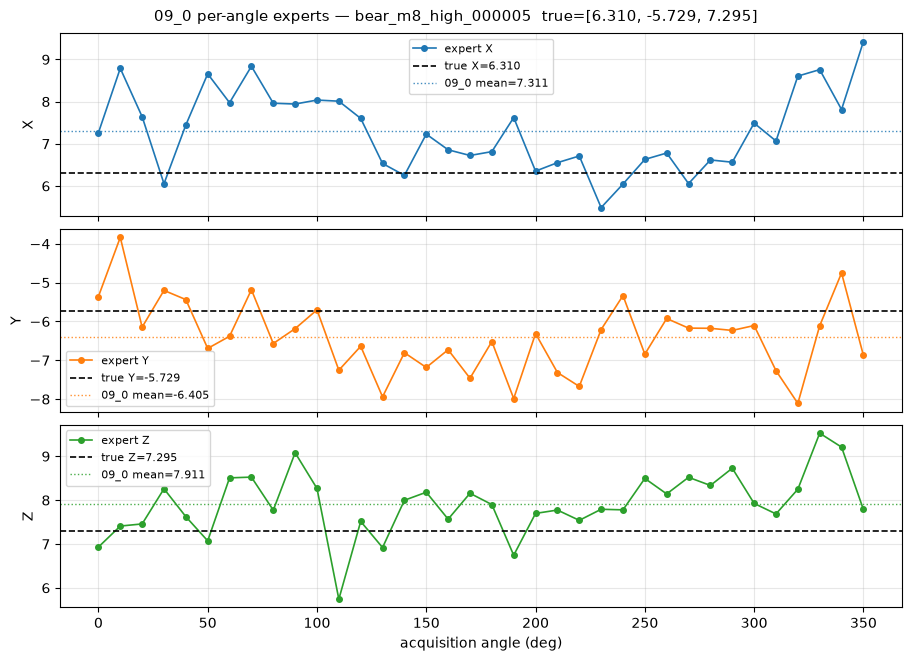

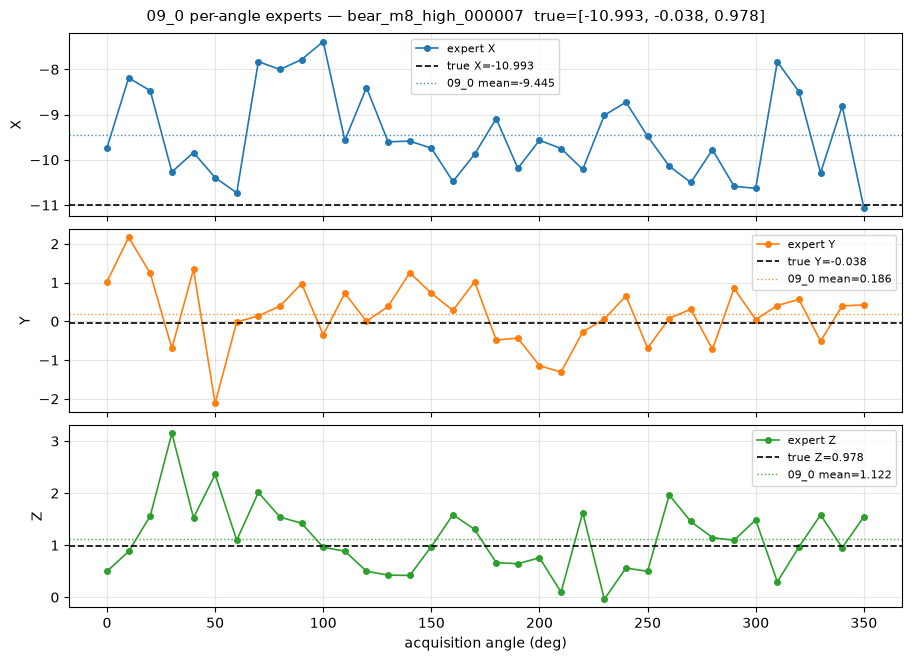

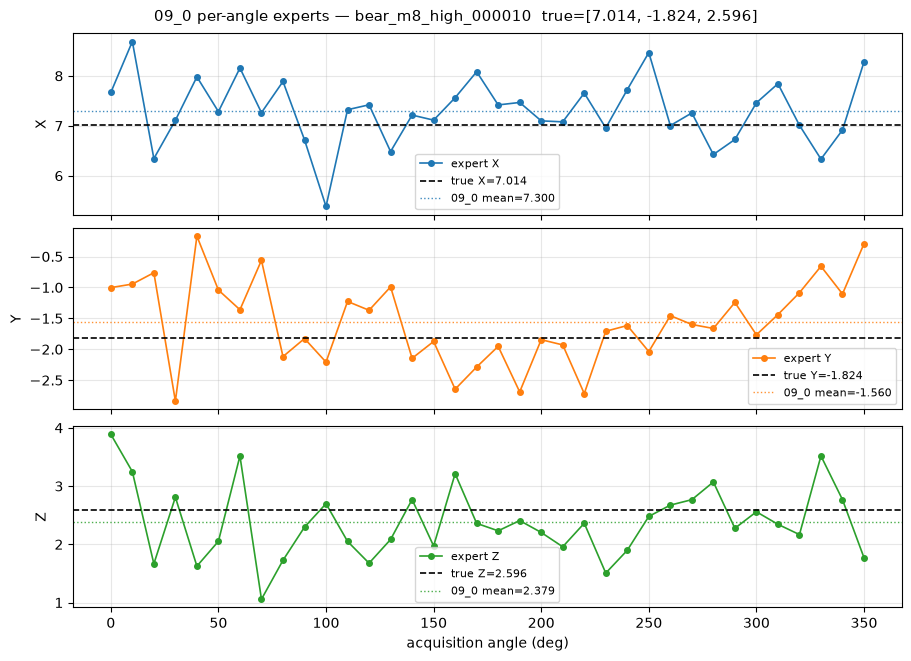

wrote checkpoints/m9/m09_0_bias_vs_expert_std_validation.csv


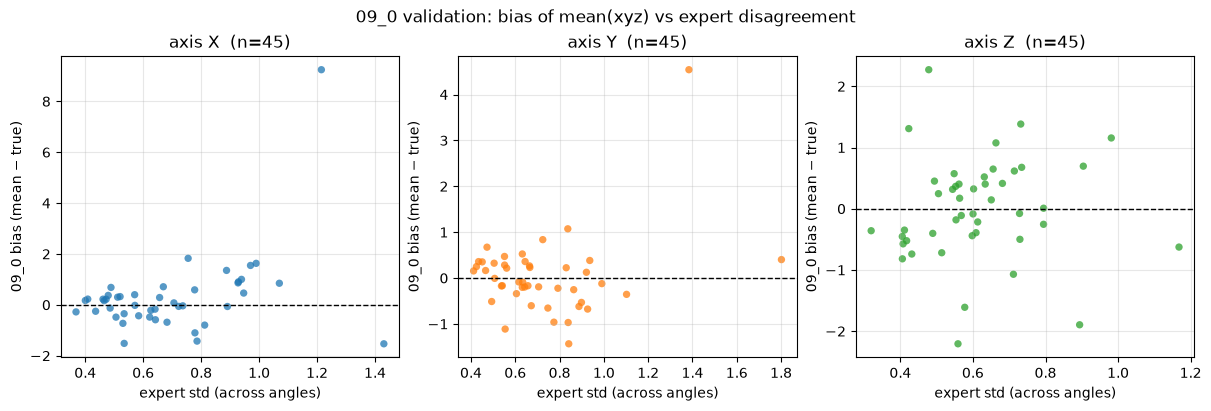

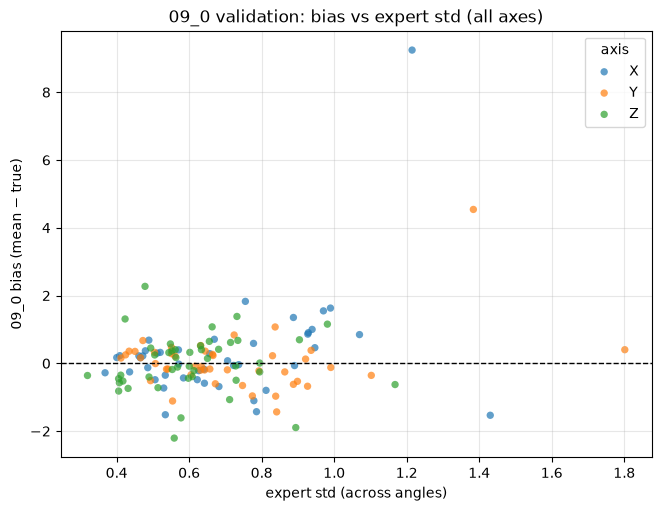

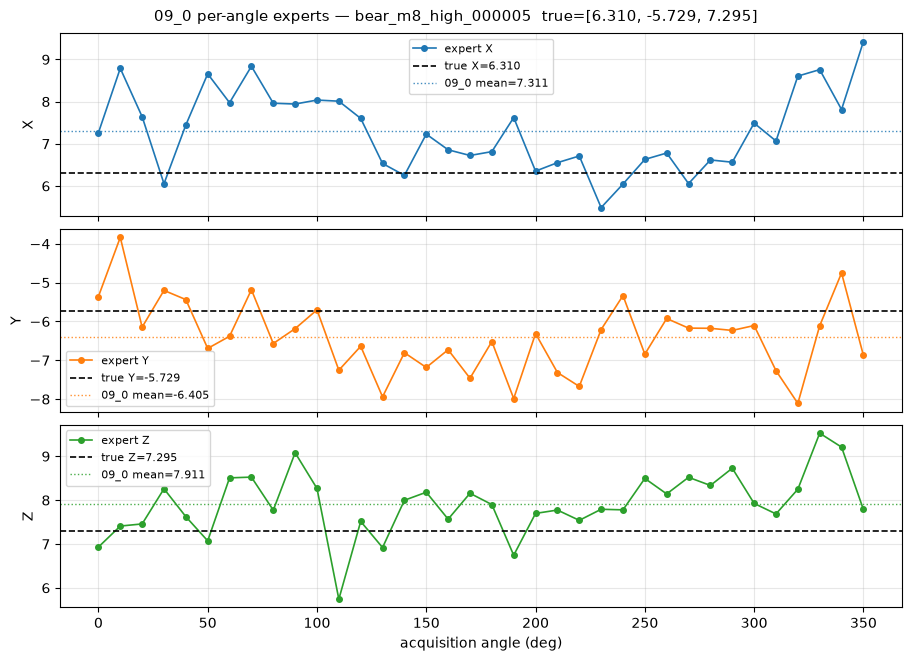

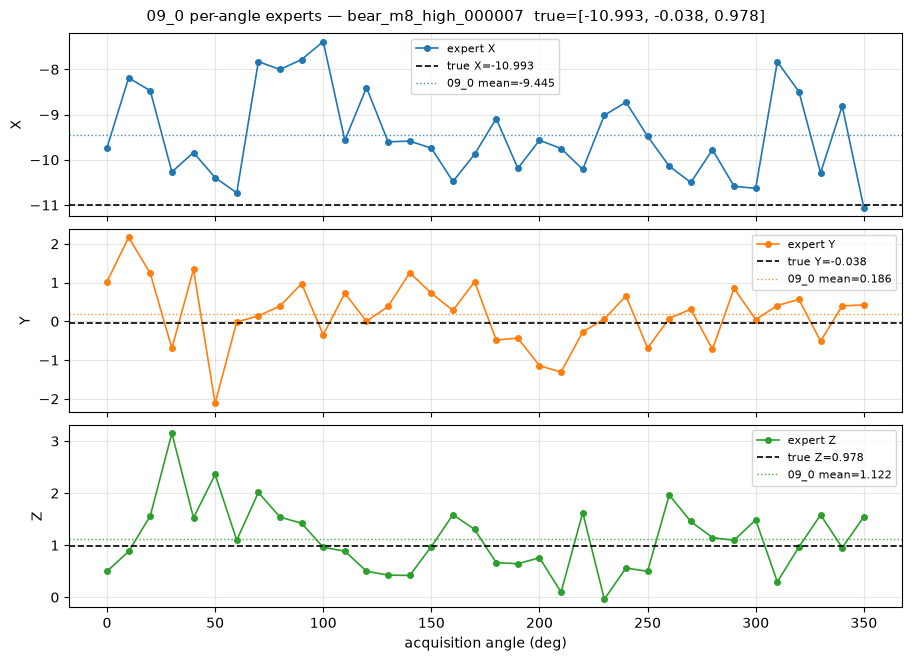

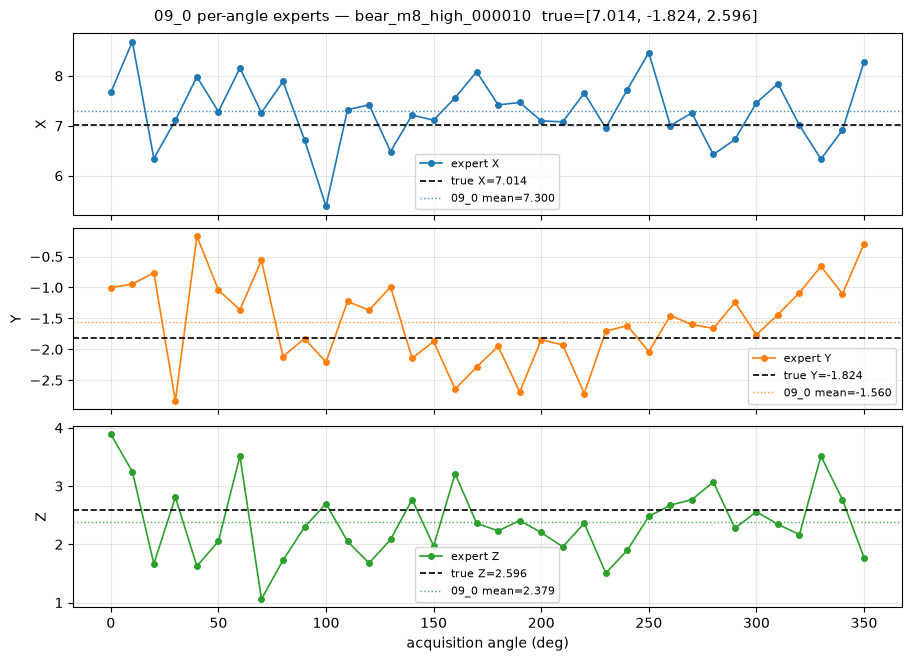

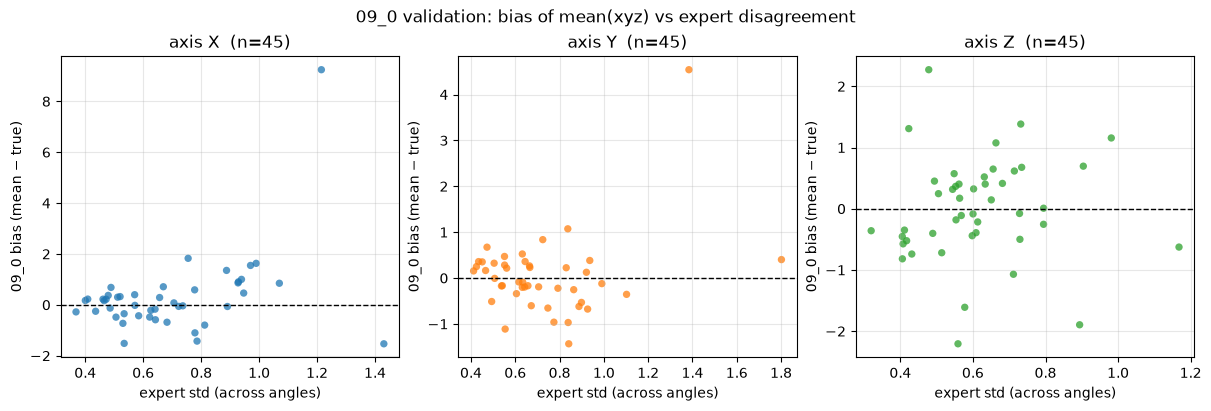

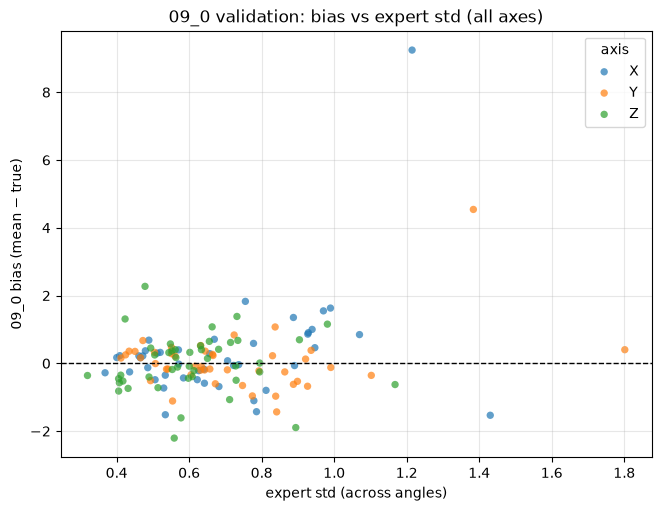

In [5]:
val_ds = m9_0_split_dataset(out, split="validation")
for fig in plot_m9_0_per_angle_experts(
    bank=out.bank,
    dataset=val_ds,
    x_field=out.extra["x_field"],
    angles=out.view_angles,
    device=device,
):
    display(fig)

bias_df = collect_m9_0_bias_vs_std(
    bank=out.bank,
    dataset=val_ds,
    x_field=out.extra["x_field"],
    angles=out.view_angles,
    device=device,
)
bias_path = out.results_dir / "m09_0_bias_vs_expert_std_validation.csv"
bias_df.to_csv(bias_path, index=False)
print(f"wrote {display_path(bias_path)}")
fig_axes, fig_all = plot_m9_0_bias_vs_expert_std(bias_df)
display(fig_axes)
display(fig_all)


## Interpretation

```text
Mean of expert xyz only modestly improves on a single view.
Averaging cannot remove shared bias — only uncorrelated noise.
Learned fusion (09_1) asks whether frozen Fourier h_i still carry usable structure.
```
